In [14]:
import sys
print(sys.executable)


c:\Users\isabe\anaconda3\python.exe


In [2]:
!pip install psycopg2-binary


The %sql command uses SQLAlchemy to connect the database, but it needs a separate driver to communicate with PostgreSQL, which is psycopg2. 

In [ ]:
!pip install jupysql

In [15]:
%load_ext sql
%sql postgresql://postgres@localhost:5432/northwind


The sql extension is already loaded. To reload it, use:
  %reload_ext sql


In [16]:
%config SqlMagic.displaylimit = 0 

In [12]:
%sql SELECT * FROM customers LIMIT 5;


Running query in 'postgresql://postgres@localhost:5432/northwind'

5 rows affected.

customer_id,company_name,contact_name,contact_title,address,city,region,postal_code,country,phone,fax
ALFKI,Alfreds Futterkiste,Maria Anders,Sales Representative,Obere Str. 57,Berlin,None,12209,Germany,030-0074321,030-0076545
ANATR,Ana Trujillo Emparedados y helados,Ana Trujillo,Owner,Avda. de la Constitución 2222,México D.F.,None,05021,Mexico,(5) 555-4729,(5) 555-3745
ANTON,Antonio Moreno Taquería,Antonio Moreno,Owner,Mataderos 2312,México D.F.,None,05023,Mexico,(5) 555-3932,None
AROUT,Around the Horn,Thomas Hardy,Sales Representative,120 Hanover Sq.,London,None,WA1 1DP,UK,(171) 555-7788,(171) 555-6750
BERGS,Berglunds snabbköp,Christina Berglund,Order Administrator,Berguvsvägen 8,Luleå,None,S-958 22,Sweden,0921-12 34 65,0921-12 34 67


In [13]:
%%sql
SELECT table_name AS name,
       table_type AS type
  FROM information_schema.tables
 WHERE table_schema = 'public' AND table_type IN ('BASE TABLE', 'VIEW');

Running query in 'postgresql://postgres@localhost:5432/northwind'

14 rows affected.

name,type
territories,BASE TABLE
order_details,BASE TABLE
employee_territories,BASE TABLE
us_states,BASE TABLE
customers,BASE TABLE
orders,BASE TABLE
employees,BASE TABLE
shippers,BASE TABLE
products,BASE TABLE
categories,BASE TABLE


In [15]:
%%sql
ALTER TABLE employees
DROP COLUMN photo;

Running query in 'postgresql://postgres@localhost:5432/northwind'

++
||
++
++

In [ ]:
# %%sql
# DROP VIEW IF EXISTS detailed_order;

Running query in 'postgresql://postgres@localhost:5432/northwind'

++
||
++
++

### Combine Customers and Orders

I joined the `customers` and `orders` tables on `customer_id` and saved the result as the `detailed_order` view. This combines customer details (company, contact, country, city, region) with order details (order date, shipped date, ship destination, employee) into a single view, so future analysis won't require repeating this join.

In [3]:
%%sql
CREATE OR REPLACE VIEW detailed_order AS
       SELECT c.customer_id,
       c.country,
       c.city,
       c.region,
       c.company_name,
       c.contact_name,
       o.order_id,
       o.order_date,
       o.shipped_date,
       o.ship_country,
       o.ship_city,
       o.employee_id
         FROM customers as c
         JOIN orders as o
           ON c.customer_id=o.customer_id;
SELECT * FROM detailed_order
LIMIT 10;


Running query in 'postgresql://postgres@localhost:5432/northwind'

10 rows affected.

customer_id,country,city,region,company_name,contact_name,order_id,order_date,shipped_date,ship_country,ship_city,employee_id
VINET,France,Reims,None,Vins et alcools Chevalier,Paul Henriot,10248,1996-07-04,1996-07-16,France,Reims,5
TOMSP,Germany,Münster,None,Toms Spezialitäten,Karin Josephs,10249,1996-07-05,1996-07-10,Germany,Münster,6
HANAR,Brazil,Rio de Janeiro,RJ,Hanari Carnes,Mario Pontes,10250,1996-07-08,1996-07-12,Brazil,Rio de Janeiro,4
VICTE,France,Lyon,None,Victuailles en stock,Mary Saveley,10251,1996-07-08,1996-07-15,France,Lyon,3
SUPRD,Belgium,Charleroi,None,Suprêmes délices,Pascale Cartrain,10252,1996-07-09,1996-07-11,Belgium,Charleroi,4
HANAR,Brazil,Rio de Janeiro,RJ,Hanari Carnes,Mario Pontes,10253,1996-07-10,1996-07-16,Brazil,Rio de Janeiro,3
CHOPS,Switzerland,Bern,None,Chop-suey Chinese,Yang Wang,10254,1996-07-11,1996-07-23,Switzerland,Bern,5
RICSU,Switzerland,Genève,None,Richter Supermarkt,Michael Holz,10255,1996-07-12,1996-07-15,Switzerland,Genève,9
WELLI,Brazil,Resende,SP,Wellington Importadora,Paula Parente,10256,1996-07-15,1996-07-17,Brazil,Resende,3
HILAA,Venezuela,San Cristóbal,Táchira,HILARION-Abastos,Carlos Hernández,10257,1996-07-16,1996-07-22,Venezuela,San Cristóbal,4


### Add Product Details to Orders

I joined `order_details`, `products`, and `orders` (via the `detailed_order` view) to bring in the product name and quantity for each order line, saving the result as the `detailed_order_info` view. This gives a complete, line-item-level view of what was ordered, so future analysis won't require repeating this join.

In [15]:
%%sql
DROP VIEW detailed_order_info

Running query in 'postgresql://postgres@localhost:5432/northwind'

++
||
++
++

In [4]:
%%sql
CREATE OR REPLACE VIEW detailed_order_info as 
      SELECT od.order_id, 
             od.product_id,
             od.quantity,
             od.unit_price,
             od.discount,
             p.product_name, 
             p.category_id
              
        FROM detailed_order as de
        JOIN employees as e
          ON e.employee_id=de.employee_id
        JOIN order_details as od
          ON de.order_id=od.order_id
        JOIN products as p
          ON p.product_id=od.product_id;
       
SELECT * FROM detailed_order_info
LIMIT 10


Running query in 'postgresql://postgres@localhost:5432/northwind'

10 rows affected.

order_id,product_id,quantity,unit_price,discount,product_name,category_id
10248,11,12,14.0,0.0,Queso Cabrales,4
10248,42,10,9.8,0.0,Singaporean Hokkien Fried Mee,5
10248,72,5,34.8,0.0,Mozzarella di Giovanni,4
10249,14,9,18.6,0.0,Tofu,7
10249,51,40,42.4,0.0,Manjimup Dried Apples,7
10250,41,10,7.7,0.0,Jack's New England Clam Chowder,8
10250,51,35,42.4,0.15,Manjimup Dried Apples,7
10250,65,15,16.8,0.15,Louisiana Fiery Hot Pepper Sauce,2
10251,22,6,16.8,0.05,Gustaf's Knäckebröd,5
10251,57,15,15.6,0.05,Ravioli Angelo,5


### Combine Orders with Employees

I joined `orders` with `customers` and `employees`, saving the result as the `orders_with_employees` view. I used a `LEFT JOIN` on `employees` (instead of an inner join) so that every order is kept even if its `employee_id` doesn't match a valid employee — for example due to a system error or missing data. This way, orders with no matching employee still show up with `NULL` employee fields instead of being silently dropped, making it easier to spot and investigate that kind of data issue.

In [ ]:
%%sql
CREATE OR REPLACE VIEW orders_with_employees AS
SELECT 
    o.order_id,
    c.customer_id, 
    c.contact_name, 
    e.employee_id,
    e.first_name || ' ' || e.last_name AS employee_full_name,
    e.title

FROM orders AS o  
JOIN customers AS c
    ON o.customer_id = c.customer_id
LEFT JOIN employees AS e
    ON o.employee_id = e.employee_id;

SELECT * from orders_with_employees
LIMIT 10

Running query in 'postgresql://postgres@localhost:5432/northwind'

10 rows affected.

order_id,customer_id,contact_name,employee_id,employee_full_name,title
10248,VINET,Paul Henriot,5,Steven Buchanan,Sales Manager
10249,TOMSP,Karin Josephs,6,Michael Suyama,Sales Representative
10250,HANAR,Mario Pontes,4,Margaret Peacock,Sales Representative
10251,VICTE,Mary Saveley,3,Janet Leverling,Sales Representative
10252,SUPRD,Pascale Cartrain,4,Margaret Peacock,Sales Representative
10253,HANAR,Mario Pontes,3,Janet Leverling,Sales Representative
10254,CHOPS,Yang Wang,5,Steven Buchanan,Sales Manager
10255,RICSU,Michael Holz,9,Anne Dodsworth,Sales Representative
10256,WELLI,Paula Parente,3,Janet Leverling,Sales Representative
10257,HILAA,Carlos Hernández,4,Margaret Peacock,Sales Representative


### Rank Employees by Total Sales

I used a CTE (`rank_employees`) to calculate each employee's total sales, joining `employees` to `orders` and `order_details` (with `LEFT JOIN`s so employees with no orders still appear) and summing `unit_price * quantity * (1 - discount)` per employee. Within the same CTE, I applied `RANK()` with an `OVER (ORDER BY ... DESC)` clause to assign each employee a sales rank, with ties receiving the same rank. The main query simply selects the results, giving each employee's total sales alongside their rank.

In [11]:
%%sql
WITH rank_employees AS (
       SELECT e.employee_id,
              e.first_name || ' ' || e.last_name AS full_name,
              e.title,
              ROUND(SUM(od.unit_price * od.quantity * (1 - od.discount))::NUMERIC, 2) AS total_sales,
              RANK() OVER (ORDER BY SUM(od.unit_price * od.quantity * (1 - od.discount)) DESC) AS sales_rank
         FROM employees as e
    LEFT JOIN orders as o
           ON o.employee_id = e.employee_id
    LEFT JOIN order_details as od
           ON od.order_id = o.order_id
        GROUP BY e.employee_id, full_name, title
)
SELECT *
  FROM rank_employees;

Running query in 'postgresql://postgres@localhost:5432/northwind'

9 rows affected.

employee_id,full_name,title,total_sales,sales_rank
4,Margaret Peacock,Sales Representative,232890.85,1
3,Janet Leverling,Sales Representative,202812.84,2
1,Nancy Davolio,Sales Representative,192107.60,3
2,Andrew Fuller,"Vice President, Sales",166537.76,4
8,Laura Callahan,Inside Sales Coordinator,126862.28,5
7,Robert King,Sales Representative,124568.23,6
9,Anne Dodsworth,Sales Representative,77308.07,7
6,Michael Suyama,Sales Representative,73913.13,8
5,Steven Buchanan,Sales Manager,68792.28,9


**Analysis:** **Sales Representatives take up most of the top ranks** in this table. That's not too surprising on its own, since Sales Representative is likely the most common title at the company — with more people in that group, it's more likely that some of them will land near the top just by having more employees in the pool. To fairly compare *titles* rather than individuals, **the next step would be to group by title, so each title is represented once**, instead of letting the title with the most employees dominate the individual-level ranking.

### Rank Employees by Total Sales Within Each Title

I extended the previous ranking query by adding `PARTITION BY e.title` to the `RANK()` window function. Instead of ranking all employees against each other, this resets the ranking within each job title group, so `RANK()` now shows how each employee's total sales compares only to peers who share the same `title` (e.g., ranking Sales Representatives against other Sales Representatives, separately from Sales Managers).

In [10]:
%%sql
WITH rank_employees AS (
       SELECT e.employee_id,
              e.first_name || ' ' || e.last_name AS full_name,
              e.title,
              ROUND(SUM(od.unit_price * od.quantity * (1 - od.discount))::NUMERIC, 2) AS total_sales,
              RANK() OVER (PARTITION BY e.title ORDER BY SUM(od.unit_price * od.quantity * (1 - od.discount)) DESC) AS sales_rank
         FROM employees as e
    LEFT JOIN orders as o
           ON o.employee_id = e.employee_id
    LEFT JOIN order_details as od
           ON od.order_id = o.order_id
        GROUP BY e.employee_id, full_name, title
)
SELECT *
  FROM rank_employees;

Running query in 'postgresql://postgres@localhost:5432/northwind'

9 rows affected.

employee_id,full_name,title,total_sales,sales_rank
8,Laura Callahan,Inside Sales Coordinator,126862.28,1
5,Steven Buchanan,Sales Manager,68792.28,1
4,Margaret Peacock,Sales Representative,232890.85,1
3,Janet Leverling,Sales Representative,202812.84,2
1,Nancy Davolio,Sales Representative,192107.60,3
7,Robert King,Sales Representative,124568.23,4
9,Anne Dodsworth,Sales Representative,77308.07,5
6,Michael Suyama,Sales Representative,73913.13,6
2,Andrew Fuller,"Vice President, Sales",166537.76,1


In [23]:
%%sql
SELECT title, COUNT(title)
FROM employees
GROUP BY title


Running query in 'postgresql://postgres@localhost:5432/northwind'

4 rows affected.

title,count
"Vice President, Sales",1
Inside Sales Coordinator,1
Sales Representative,6
Sales Manager,1


**Analysis:** This is a case where `PARTITION BY title` needs to be read carefully rather than taken at face value. Checking `employees`, all `4` titles at the company are sales-related (`Sales Representative`, `Sales Manager`, `Vice President, Sales`, `Inside Sales Coordinator`), but **only `Sales Representative` actually has more than one person — `6` employees — while the other three titles have exactly one employee each**. So for those single-employee titles, "rank 1 within title" isn't really a performance signal; it's just an artifact of there being no one else to rank against. **The only title where the within-group rank is comparing real peers is `Sales Representative`.**

### Monthly Sales with Running Total

I used a CTE (`joined_table`) to calculate total sales per month, joining `orders` to `order_details` and summing `unit_price * quantity * (1 - discount)`, grouped by month via `DATE_TRUNC('month', order_date)`. The main query then applies `SUM(total_sales_per_month) OVER (ORDER BY Month)` to produce a running total, so each row shows both that month's sales and the cumulative sales up to and including that month.

In [ ]:
%%sql
WITH joined_table AS (
    SELECT DATE_TRUNC('month', order_date) as Month,                            
        SUM(od.unit_price*od.quantity*(1-od.discount)) as total_sales_per_month
        FROM orders as o
        JOIN order_details as od
        ON o.order_id=od.order_id
       GROUP BY Month
)

SELECT *, SUM(total_sales_per_month) 
          OVER(order by Month) as running_totals
  FROM joined_table
 ORDER BY Month

Running query in 'postgresql://postgres@localhost:5432/northwind'

23 rows affected.

month,total_sales_per_month,running_totals
1996-07-01 00:00:00+00:00,27861.89512966156,27861.89512966156
1996-08-01 00:00:00+00:00,25485.275070743264,53347.17020040483
1996-09-01 00:00:00+00:00,26381.400132587554,79728.57033299239
1996-10-01 00:00:00+00:00,37515.72494547888,117244.29527847127
1996-11-01 00:00:00+00:00,45600.04521113701,162844.3404896083
1996-12-01 00:00:00+00:00,45239.630493214434,208083.97098282274
1997-01-01 00:00:00+00:00,61258.0701679784,269342.0411508011
1997-02-01 00:00:00+00:00,38483.6349503243,307825.6761011254
1997-03-01 00:00:00+00:00,38547.22010972678,346372.8962108522
1997-04-01 00:00:00+00:00,53032.95238894149,399405.8485997937


**Analysis:** The running total confirms Northwind's revenue grew steadily over the two years, but the month-to-month figures show it wasn't a smooth climb. Early on (1996-07 to 1996-12), monthly sales stayed in a tight `$26K–$45K` band. 1997 was more volatile — January spiked to `$61K`, then dropped in February. Between 1997-07 and 1997-12 sales trend upward overall, but with dips in `1997-08` and `1997-11`, before climbing steadily from `1998-01` through `1998-04`. There may be a promotion or seasonal event behind these spikes worth investigating, so the same strategy could be reused for future marketing. **One exception: `1998-05` shows a sharp drop, but that's because the dataset's order records may cut off mid-month, not a real sales decline — it should be excluded from this trend read.**

### Month-over-Month Growth Rate

Used `LAG(total_sales_per_month) OVER (ORDER BY Month)` to line up each month's sales next to the previous month's, then took the percent change between them as `growth_rate`.

In [26]:
%%sql
WITH total_sales_per_month AS (
     SELECT DATE_TRUNC('month', order_date) as Month,
            SUM(od.unit_price*od.quantity*(1-od.discount)) as current_month_sales
            FROM orders as o
            JOIN order_details as od
              ON o.order_id=od.order_id
           GROUP BY Month),
prev_month_sales AS (
    SELECT Month, current_month_sales, LAG(current_month_sales) OVER(
                             ORDER by Month) as prev_month_sales
      FROM total_sales_per_month
     GROUP BY Month, current_month_sales
)

SELECT Month, prev_month_sales, current_month_sales, ((current_month_sales-prev_month_sales)/prev_month_sales*100) as growth_rate
  FROM prev_month_sales 

Running query in 'postgresql://postgres@localhost:5432/northwind'

23 rows affected.

month,prev_month_sales,current_month_sales,growth_rate
1996-07-01 00:00:00+00:00,None,27861.89512966156,None
1996-08-01 00:00:00+00:00,27861.89512966156,25485.275070743264,-8.530001451294545
1996-09-01 00:00:00+00:00,25485.275070743264,26381.400132587554,3.51624637896504
1996-10-01 00:00:00+00:00,26381.400132587554,37515.72494547888,42.20520805162909
1996-11-01 00:00:00+00:00,37515.72494547888,45600.04521113701,21.54915112904513
1996-12-01 00:00:00+00:00,45600.04521113701,45239.630493214434,-0.7903823696967553
1997-01-01 00:00:00+00:00,45239.630493214434,61258.0701679784,35.40798079057388
1997-02-01 00:00:00+00:00,61258.0701679784,38483.6349503243,-37.17785290199861
1997-03-01 00:00:00+00:00,38483.6349503243,38547.22010972678,0.16522649038887202
1997-04-01 00:00:00+00:00,38547.22010972678,53032.95238894149,37.579187910257275


**Analysis:** MoM growth swings sharply between positive and negative (`+35.4%` → `-37.2%`, `+37.6%` → `-32.4%`) rather than trending smoothly. This pattern suggests sales are uneven month to month — big orders land in some months and fade in the next — rather than showing steady growth or decline. The `-85.2%` in `1998-05` is a data artifact (partial month) and should be excluded. A 3-month grouping is needed to smooth this noise and reveal the actual trend.

### 3-Month Moving Average Growth Rate

The raw MoM numbers were too jumpy to read a trend from, so I tried averaging the last 3 months instead — `AVG(current_month_sales) OVER (ORDER BY Month ROWS BETWEEN 2 PRECEDING AND CURRENT ROW)` — and compared each month against that instead of just the month before.

In [17]:
%%sql
WITH total_sales_per_month AS (
     SELECT DATE_TRUNC('month', order_date) as Month,
            SUM(od.unit_price*od.quantity*(1-od.discount)) as current_month_sales
            FROM orders as o
            JOIN order_details as od
              ON o.order_id=od.order_id
           GROUP BY Month),
prev_months_sales AS (
    SELECT Month, current_month_sales,
           AVG(current_month_sales) OVER(
                 ORDER by Month ROWS BETWEEN 2 PRECEDING AND CURRENT ROW) as prev_3_months_sales,
           COUNT(*) OVER(
                 ORDER by Month ROWS BETWEEN 2 PRECEDING AND CURRENT ROW) as months_in_window
      FROM total_sales_per_month
     GROUP BY Month, current_month_sales
)

SELECT Month, ((current_month_sales-prev_3_months_sales)/prev_3_months_sales*100) as growth_rate
  FROM prev_months_sales
 WHERE months_in_window = 3

Running query in 'postgresql://postgres@localhost:5432/northwind'

21 rows affected.

month,growth_rate
1996-09-01 00:00:00+00:00,-0.7329492210747715
1996-10-01 00:00:00+00:00,25.91648316565757
1996-11-01 00:00:00+00:00,24.93485929553713
1996-12-01 00:00:00+00:00,5.736798601799002
1997-01-01 00:00:00+00:00,20.826386643622204
1997-02-01 00:00:00+00:00,-20.368436141098964
1997-03-01 00:00:00+00:00,-16.376774106462438
1997-04-01 00:00:00+00:00,22.323696566563036
1997-05-01 00:00:00+00:00,10.994941091066028
1997-06-01 00:00:00+00:00,-23.808731107617756


**Analysis:** The 3-month moving average dampens most of the raw MoM swings (e.g., `1997-12`'s `+64.0%` becomes `+17.9%`), making the underlying trend clearer: fairly consistent growth from `1997-07` through `1998-04`. `1998-05` still shows a sharp `-77.7%` drop even after smoothing, since the incomplete month is part of its own average — it should still be excluded from any trend read. `1996-07` and `1996-08` are excluded from the results entirely, since there aren't yet 3 months of data to build a full moving average from.

### Visualizing MoM vs. 3-Month Moving Average Growth Rate

To see the noise-reduction effect directly instead of just comparing numbers in a table, I pulled both growth rate series (raw MoM and the 3-month moving average) into a single query, loaded the result into a pandas DataFrame, and plotted them as a line chart. The raw MoM line should look jagged, while the 3-month moving average line should trace a smoother path through it.

In [18]:
%%sql growth_result <<
WITH total_sales_per_month AS (
     SELECT DATE_TRUNC('month', order_date) as month,
            SUM(od.unit_price*od.quantity*(1-od.discount)) as current_month_sales
       FROM orders as o
       JOIN order_details as od
         ON o.order_id=od.order_id
      GROUP BY month
),
growth_calc AS (
    SELECT month,
           current_month_sales,
           LAG(current_month_sales) OVER (ORDER BY month) as prev_month_sales,
           AVG(current_month_sales) OVER (
               ORDER BY month ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
           ) as moving_avg_3mon,
           COUNT(*) OVER (
               ORDER BY month ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
           ) as months_in_window
      FROM total_sales_per_month
)
SELECT month,
       (current_month_sales - prev_month_sales) / prev_month_sales * 100 as mom_growth_rate,
       (current_month_sales - moving_avg_3mon) / moving_avg_3mon * 100 as moving_avg_growth_rate
  FROM growth_calc
 WHERE months_in_window = 3
 ORDER BY month;

Running query in 'postgresql://postgres@localhost:5432/northwind'

21 rows affected.

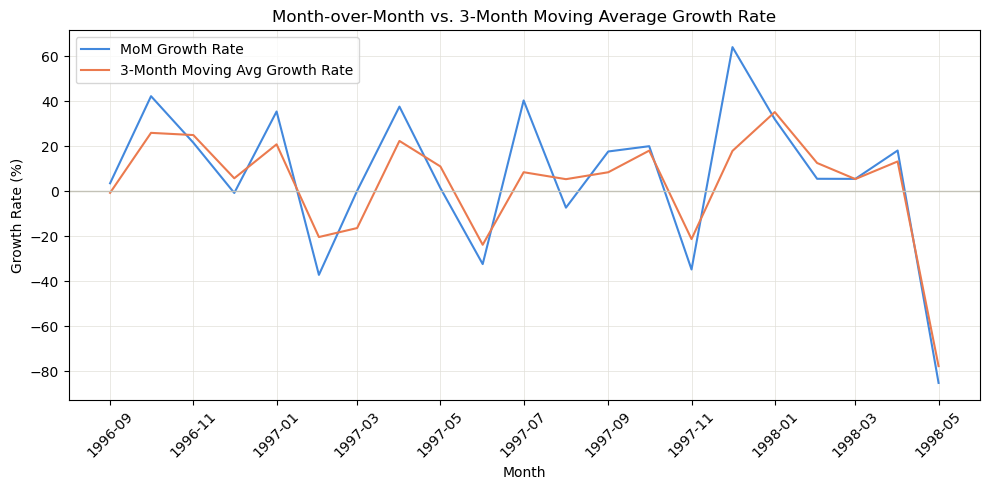

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

df = growth_result.DataFrame()
df['month'] = pd.to_datetime(df['month'])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df['month'], df['mom_growth_rate'], color="#4288dd", label='MoM Growth Rate')
ax.plot(df['month'], df['moving_avg_growth_rate'], color="#eb7a4e",  label='3-Month Moving Avg Growth Rate')
ax.axhline(0, color='#c3c2b7', linewidth=1)

ax.set_title('Month-over-Month vs. 3-Month Moving Average Growth Rate')
ax.set_xlabel('Month')
ax.set_ylabel('Growth Rate (%)')
ax.legend()
ax.grid(True, color='#e1e0d9', linewidth=0.5)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Customer Order Frequency vs. Average

I used a CTE (`customer_order_values`) to count each customer's total orders and compare it against the overall average order count via `AVG(COUNT(...)) OVER()`. The main query then labels each customer as `'Above Average'` or `'Average/Below Average'` based on that comparison, making it easy to spot which customers order more or less frequently than the typical customer.

In [38]:
%%sql
WITH customer_order_values AS (
    SELECT c.customer_id,
           c.contact_name, 
           c.country,
           COUNT(c.customer_id) as number_of_orders,
           ROUND(AVG(COUNT(c.customer_id)) OVER(),2) as average_order
    FROM orders as o
    JOIN customers as c
      ON c.customer_id=o.customer_id
   GROUP BY c.customer_id, c.contact_name, c.country
)

SELECT *,
CASE  
WHEN number_of_orders>average_order
THEN 'Above Average'
WHEN number_of_orders<average_order
THEN 'Average/Below Average'
END as order_category
FROM customer_order_values
ORDER BY number_of_orders DESC
LIMIT 10;

Running query in 'postgresql://postgres@localhost:5432/northwind'

10 rows affected.

customer_id,contact_name,country,number_of_orders,average_order,order_category
SAVEA,Jose Pavarotti,USA,31,9.33,Above Average
ERNSH,Roland Mendel,Austria,30,9.33,Above Average
QUICK,Horst Kloss,Germany,28,9.33,Above Average
FOLKO,Maria Larsson,Sweden,19,9.33,Above Average
HUNGO,Patricia McKenna,Ireland,19,9.33,Above Average
RATTC,Paula Wilson,USA,18,9.33,Above Average
BERGS,Christina Berglund,Sweden,18,9.33,Above Average
HILAA,Carlos Hernández,Venezuela,18,9.33,Above Average
BONAP,Laurence Lebihan,France,17,9.33,Above Average
FRANK,Peter Franken,Germany,15,9.33,Above Average


In [9]:
%%sql customer_result <<
WITH customer_order_values AS (
    SELECT c.customer_id,
           c.contact_name, 
           c.country,
           COUNT(c.customer_id) as number_of_orders,
           ROUND(AVG(COUNT(c.customer_id)) OVER(),2) as average_order
    FROM orders as o
    JOIN customers as c
      ON c.customer_id=o.customer_id
   GROUP BY c.customer_id, c.contact_name, c.country
)

SELECT *,
CASE  
WHEN number_of_orders>average_order
THEN 'Above Average'
WHEN number_of_orders<average_order
THEN 'Average/Below Average'
END as order_category
FROM customer_order_values
ORDER BY number_of_orders DESC

Running query in 'postgresql://postgres@localhost:5432/northwind'

89 rows affected.

In [10]:
import pandas as pd

df = customer_result.DataFrame()
df['order_category'].value_counts()


order_category
Average/Below Average    50
Above Average            39
Name: count, dtype: int64

Went with a histogram here since I wanted to see how `number_of_orders` is spread out across customers, not compare separate categories or a trend over time.

C:\Users\isabe\AppData\Local\Temp\ipykernel_13888\3724590394.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


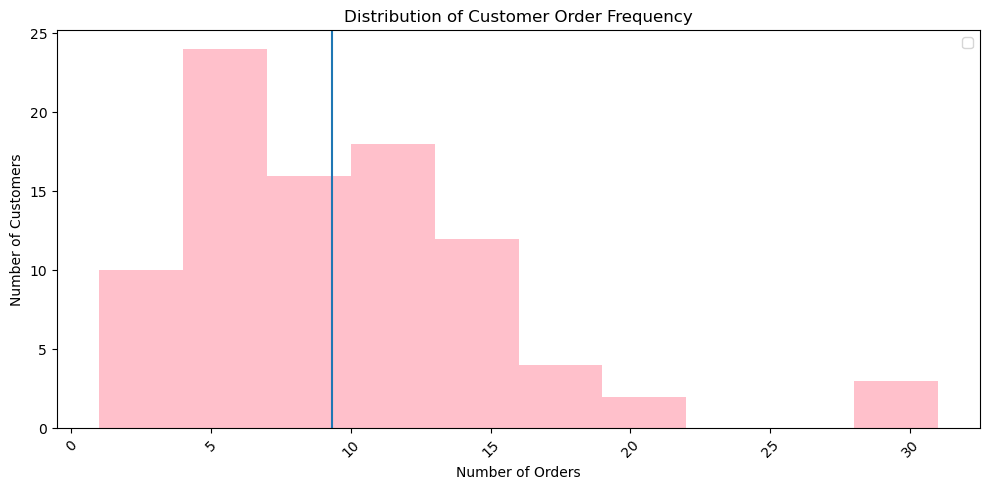

In [11]:
import matplotlib.pyplot as plt

fig,ax=plt.subplots(figsize=(10,5))
ax.set_title('Distribution of Customer Order Frequency')
ax.set_xlabel('Number of Orders')
ax.set_ylabel('Number of Customers')
avg_value=df['average_order'].iloc[0]
ax.axvline(avg_value)

ax.hist(df['number_of_orders'], bins=10, color='pink')
ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Analysis:** The histogram shows a clear **right-skewed distribution**. Most customers cluster in the low end (roughly `1`–`10` orders), while a handful of outliers sit far out on the right tail. This shape explains why the average (`9.33`) doesn't represent a **"typical"** customer: it's pulled upward by these few high-frequency buyers, which is also why only `44%` (`39` of `89`) of customers fall above it while `56%` (`50` of `89`) fall below. This gap between where most customers sit and the average line makes the skew easy to see; something the Above/Below Average numbers alone don't show.

### Order Value vs. Average, with Discount

Grouped by `customer_id` and `order_id` so each row is one order (keeping the same grain as the order-count query above), then summed each order's line items into `order_values` and averaged that order's discount rate. Compared each order's value to the overall average order value to flag it `Above Average` or `Average/Below Average`.

In [21]:
%%sql discount_order_result <<
WITH customer_order_values AS (
    SELECT c.customer_id,
           c.contact_name, 
           c.country,
           od.order_id,
           ROUND(AVG(discount::DECIMAL),2) as discount,
           SUM(unit_price*quantity*(1-discount)) AS order_values
           
     
    FROM orders as o
    JOIN customers as c
      ON c.customer_id=o.customer_id
    JOIN order_details as od
      ON od.order_id=o.order_id
   GROUP BY c.customer_id, c.contact_name, c.country,od.order_id
)

SELECT *,
CASE  
WHEN order_values>avg(order_values) OVER ()
THEN 'Above Average'
WHEN order_values<avg(order_values) OVER ()
THEN 'Average/Below Average'
END as order_category
FROM customer_order_values

ORDER BY discount DESC

Running query in 'postgresql://postgres@localhost:5432/northwind'

830 rows affected.

In [22]:
df = discount_order_result.DataFrame()
df['discount'].value_counts()


discount
0.00    450
0.05     68
0.10     65
0.20     48
0.15     39
0.25     36
0.13     25
0.08     25
0.03     24
0.07     13
0.17     10
0.11      8
0.04      7
0.19      5
0.02      3
0.06      2
0.12      1
0.09      1
Name: count, dtype: int64

Went with a scatter plot instead of bars here; some discount rates only have 1 order behind them, so averaging into bars would let those tiny samples skew the picture. Plotting every order individually shows the real spread, noise and all.

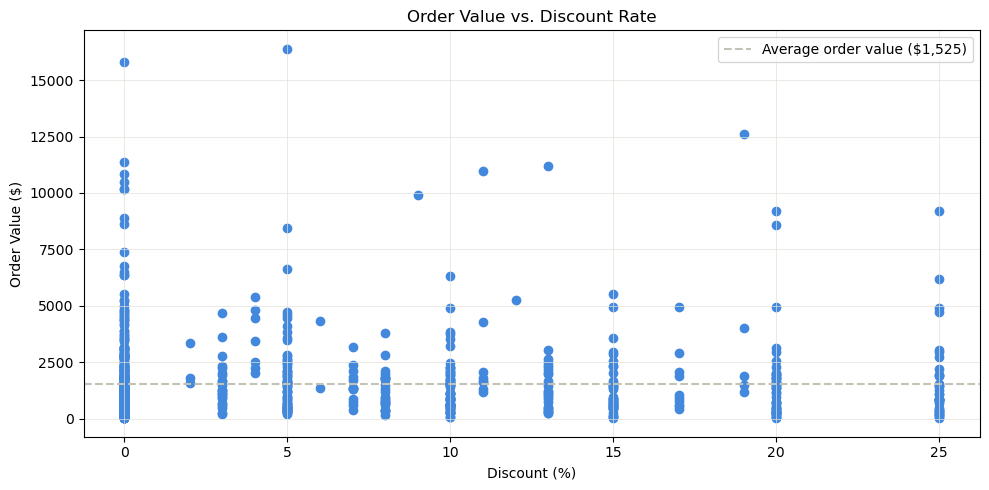

In [23]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(df['discount'] * 100, df['order_values'], color="#4288dd")

avg_value = df['order_values'].mean()
ax.axhline(avg_value, color='#c3c2b7', linestyle='--', label=f'Average order value (${avg_value:,.0f})')

ax.set_title('Order Value vs. Discount Rate')
ax.set_xlabel('Discount (%)')
ax.set_ylabel('Order Value ($)')
ax.legend()
ax.grid(True, color='#e1e0d9', linewidth=0.5)

plt.tight_layout()
plt.show()

In [24]:
df.groupby(df['discount'] > 0)['order_values'].mean()

discount
False    1375.331844
True     1702.351865
Name: order_values, dtype: float64

**Analysis:** Most points sit below the `$1,525` average line no matter the discount level. There are a few big outlier orders (up to `$16,387`) scattered across every discount tier, even `0%`. Discounted orders do average higher overall (`$1,702` vs `$1,375`), so there's some upward tendency, but it's noisy enough that I wouldn't call discount a real predictor of order size.

### Sales Percentage by Category

Got each category's total sales from `detailed_order_info`, then used `SUM() OVER()` to turn that into a % of overall sales.

In [26]:
%%sql
WITH total_sales_for_category AS (
    SELECT c.category_id, 
           c.category_name, 
           SUM(d.quantity*d.unit_price*(1-d.discount)) as                                  total_sales_for_category
    FROM detailed_order_info as d
    JOIN categories as c
      ON c.category_id=d.category_id
  GROUP BY c.category_id
)


SELECT *, (total_sales_for_category/SUM(total_sales_for_category)OVER())*100 as percentage
FROM total_sales_for_category
ORDER BY percentage DESC

Running query in 'postgresql://postgres@localhost:5432/northwind'

8 rows affected.

category_id,category_name,total_sales_for_category,percentage
1,Beverages,267868.17978624784,21.162083500729633
4,Dairy Products,234507.2845305777,18.52651084098727
3,Confections,167357.22547338586,13.221531511299172
6,Meat/Poultry,163022.3602687388,12.879069112449296
8,Seafood,131261.7365558489,10.369920875492724
2,Condiments,106047.08460955074,8.3779165607018
7,Produce,99984.58007357619,7.8989674473124385
5,Grains/Cereals,95744.58735543818,7.5640001510276695


**Analysis:** Beverages and Dairy Products alone make up almost `40%` of total revenue (`21.2%` + `18.5%`), while Grains/Cereals and Produce barely clear `7-8%` each. Just `3` of the `8` categories bring in more than half of all sales — revenue really isn't spread evenly across the catalog.

### Top 3 Products by Sales Within Each Category

Used `SUM() OVER (PARTITION BY product_id)` to get each product's total sales without collapsing the line-item rows (deduplicated with `DISTINCT`, since the window function repeats that total on every line for the product). Then ranked products within each category with `ROW_NUMBER() OVER (PARTITION BY category_id ORDER BY total_sales DESC)` and kept `row_number < 4` to get the top 3 per category.

In [25]:
%%sql
WITH total_sales_per_product AS (
    SELECT DISTINCT 
                    d.product_name,
                    c.category_id,
                    c.category_name,
                    SUM(d.unit_price*d.quantity*(1-d.discount))                               OVER(PARTITION BY product_id) as total_sales
    FROM detailed_order_info as d
    JOIN categories as c
      ON c.category_id=d.category_id
)

SELECT *
  FROM (SELECT *,ROW_NUMBER() OVER (PARTITION BY category_id
                             ORDER BY total_sales DESC) as row_number
          FROM total_sales_per_product) as ranked_products
 WHERE 4>row_number

Running query in 'postgresql://postgres@localhost:5432/northwind'

24 rows affected.

product_name,category_id,category_name,total_sales,row_number
Côte de Blaye,1,Beverages,141396.7356273254,1
Ipoh Coffee,1,Beverages,23526.699842727183,2
Chang,1,Beverages,16355.959905386866,3
Vegie-spread,2,Condiments,16701.095047264098,1
Sirop d'érable,2,Condiments,14352.599874171616,2
Louisiana Fiery Hot Pepper Sauce,2,Condiments,13869.889445907102,3
Tarte au sucre,3,Confections,47234.96997850418,1
Sir Rodney's Marmalade,3,Confections,22563.36029526442,2
Gumbär Gummibärchen,3,Confections,19849.144170827934,3
Raclette Courdavault,4,Dairy Products,71155.69990943,1


**Analysis:** The gap between the #1 and #2 product isn't consistent across categories. In Beverages, `Côte de Blaye` (`$141,397`) outsells `Ipoh Coffee` (`$23,527`) by about `6x` — a steep drop-off that points to real reliance on one product, so any supply issue, price change, or drop in demand for it would hit the whole category. Worth digging into why it sells so much better than everything else, and maybe pushing `Ipoh Coffee` harder so the category isn't riding on one SKU (Stock Keeping Unit). Condiments looks different — `Vegie-spread` (`$16,701`) and `Sirop d'érable` (`$14,353`) are close in value, so sales there are shared more evenly. Lower risk, but also no single product carrying the category.